In [1]:
from openai import OpenAI
client = OpenAI(api_key=open("gemini_api_key.txt").read().strip(),
                 base_url="https://generativelanguage.googleapis.com/v1beta/openai/")
for m in client.models.list():
    if "gemma" in m.id.lower():
        print(m.id)

models/gemma-4-26b-a4b-it
models/gemma-4-31b-it


--- Generated Data Table ---
                      Model  Hit Rate (All Genes)
0     Gemini 3.5 Lite (Low)              0.118478
1  Gemini 3.5 Lite (Medium)              0.094565
2    Gemini 3.5 Lite (High)              0.079348
3  Gemini Lite Latest (Low)              0.083696
4                 Haiku 4.5              0.095652
5                Sonnet 4.6              0.095652
6                  Llama-8b              0.042391




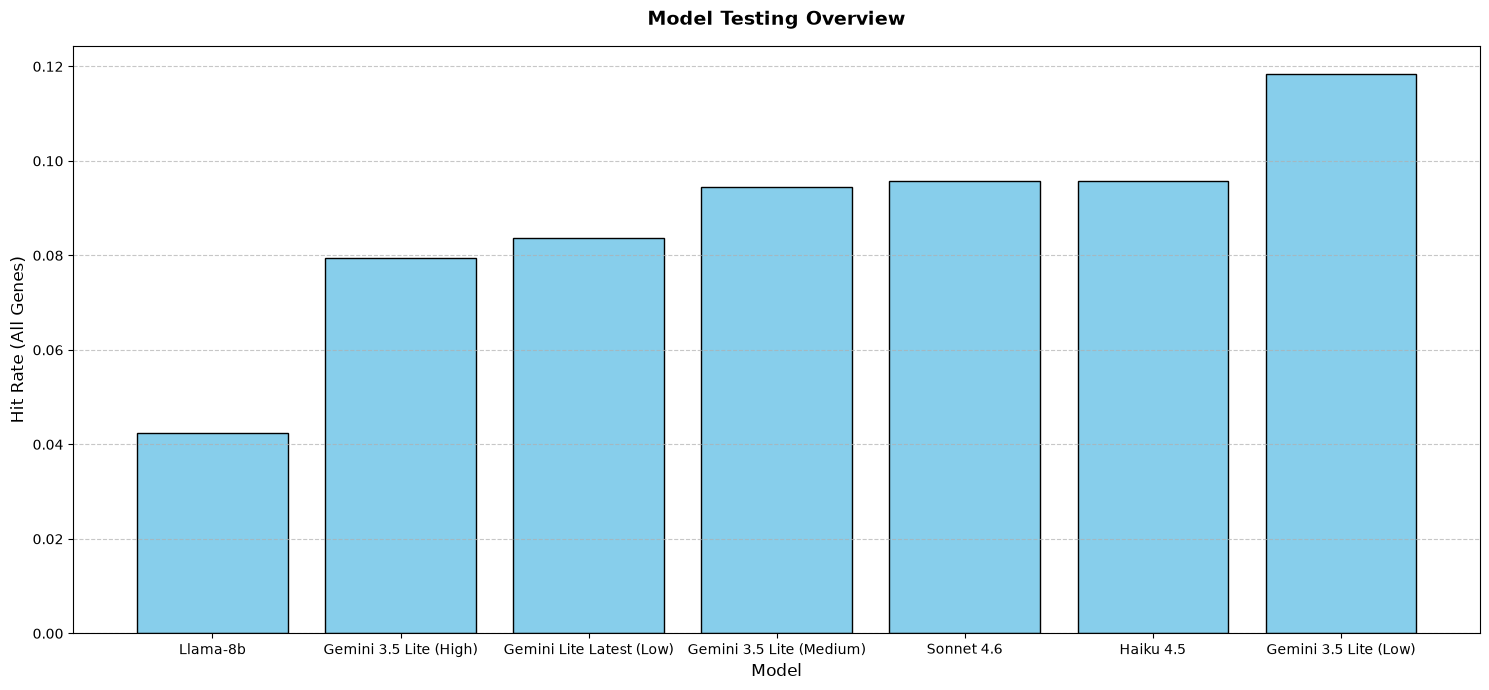

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create a table (pandas DataFrame)
data = {
    "Model": ["Gemini 3.5 Lite (Low)", "Gemini 3.5 Lite (Medium)", "Gemini 3.5 Lite (High)", "Gemini Lite Latest (Low)", "Haiku 4.5", "Sonnet 4.6", "Llama-8b"],
    "Hit Rate (All Genes)": [0.11847826086956521, 0.09456521739130434, 0.07934782608695652, 0.08369565217391305, 0.09565217391304348, 0.09565217391304348, 0.042391304347826085],
}

#tested but no final result- gemini 3.8 flash, Gemma 4-31b, GPT-oss-120b, llama 8b, qwen 3.8-27b
df = pd.DataFrame(data)
df_sorted = df.sort_values(by="Hit Rate (All Genes)", ascending=True)

# Print the table to the console so you can see it
print("--- Generated Data Table ---")
print(df)
print("\n" + "=" * 30 + "\n")


# 2. Generate a bar graph from the table
# Set the window/figure size
plt.figure(figsize=(15, 7))

# Create the vertical bar plot
# x-axis: Product categories, y-axis: Sales heights
plt.bar(df_sorted["Model"], df_sorted["Hit Rate (All Genes)"], color="skyblue", edgecolor="black")

# Add customizations to make it scannable and readable
plt.title("Model Testing Overview", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Hit Rate (All Genes)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)  # Add light gridlines for scale

# 3. Display the chart
plt.tight_layout()  # Prevents labels from getting cut off
plt.show()


In [ ]:
#check pooling efficacy
import glob
import pandas as pd

frames = []
for path in sorted(glob.glob("gemini_pool_IFNG/test/step_*_candidates.csv")):
    d = pd.read_csv(path)
    d["step"] = int(path.split("step_")[1].split("_")[0])
    frames.append(d)
cand = pd.concat(frames)

by_score = cand.groupby("confidence").agg(candidates=("gene", "size"),
                                          selected=("selected", "sum"),
                                          hits=("is_hit", "sum"))
by_score["hit_rate"] = (by_score.hits / by_score.candidates).round(3)
print(by_score.sort_index(ascending=False))

print("\nhit rate, top-128 by confidence :", round(cand[cand.selected].is_hit.mean(), 4))
print("hit rate, first 128 as listed   :", round(cand[cand.listed_position < 128].is_hit.mean(), 4))
print("hit rate, whole pool            :", round(cand.is_hit.mean(), 4))

            candidates  selected  hits  hit_rate
confidence                                      
5                   15        15     4     0.267
4                   52        52    10     0.192
3                  116        61    26     0.224
2                  155         0    11     0.071
1                   12         0     0     0.000

hit rate, top-128 by confidence : 0.1953
hit rate, first 128 as listed   : 0.2422
hit rate, whole pool            : 0.1457
